In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
# je charge le dataset
df = pd.read_csv('data/raw/Dataset of health insurance portfolio.csv', sep=';')

In [109]:
# je regarde les premieres lignes pour avoir une idee du contenu
df.head()

,ID,ID_policy,ID_insured,period,date_effect_insured,date_lapse_insured,date_effect_policy,date_lapse_policy,year_effect_insured,year_lapse_insured,...,C_H,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T,C_C
0,1_1,1,1,2017,15/06/1993,20/12/2017,15/06/1993,NaN,1993,2017.0,...,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
1,1_2,1,2,2017,15/06/1993,NaN,15/06/1993,NaN,1993,NaN,...,H1,99.0,85.0,18.0,52.0,59.0,4.0,14.0,96.0,C6
2,2_1,2,1,2017,16/06/1993,NaN,16/06/1993,NaN,1993,NaN,...,H6,100.0,94.0,26.0,11.0,85.0,7.0,1.0,100.0,C6
3,3_3,3,3,2017,15/06/1993,NaN,15/06/1993,NaN,1993,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3_5,3,5,2017,15/06/1993,NaN,15/06/1993,NaN,1993,NaN,...,H6,99.0,81.0,32.0,34.0,69.0,9.0,4.0,98.0,C6


In [110]:
# je verifie la taille du dataset
df.shape

(228711, 42)

In [111]:
# je verifie les valeurs manquantes
df.isnull().sum()

ID                           0
ID_policy                    0
ID_insured                   0
period                       0
date_effect_insured          0
date_lapse_insured      167181
date_effect_policy           0
date_lapse_policy       174568
year_effect_insured          0
year_lapse_insured      167181
year_effect_policy           0
year_lapse_policy       174568
exposure_time                0
lapse                        0
seniority_insured            0
seniority_policy             0
type_policy                  0
type_policy_dg               0
type_product                 0
reimbursement                0
new_business                 0
distribution_channel         0
gender                       0
age                          0
premium                      0
cost_claims_year             0
n_medical_services           0
n_insured_pc                 0
n_insured_mun                0
n_insured_prov               0
IICIMUN                  10886
IICIPROV                  5701
C_H     

In [112]:
# je regarde les statistiques generales
df.describe()

,ID_policy,ID_insured,period,year_effect_insured,year_lapse_insured,year_effect_policy,year_lapse_policy,lapse,seniority_insured,seniority_policy,...,n_insured_mun,n_insured_prov,C_GI,C_II,C_IE_P,C_IE_S,C_IE_T,C_GE_P,C_GE_S,C_GE_T
count,228711.000000,228711.000000,228711.000000,228711.000000,61530.000000,228711.000000,54143.000000,228711.000000,228711.000000,228711.000000,...,228711.000000,228711.000000,215498.000000,215498.000000,215498.000000,215498.000000,215498.000000,215498.000000,215498.000000,215498.000000
mean,20629.465220,13.944708,2017.990481,2005.213768,2018.156021,2004.294017,2018.156327,2.038232,12.776714,13.696464,...,5279.805943,13152.511462,81.496705,50.485411,50.484167,50.484148,50.485462,20.044887,26.658336,84.137069
std,12236.581187,95.049800,0.822491,13.053458,0.786350,13.988405,0.782587,0.423944,13.014838,13.948242,...,7409.320837,11916.610471,23.241767,28.868616,28.868581,28.868551,28.868536,17.660667,28.095859,19.854768
min,1.000000,1.000000,2017.000000,1933.000000,2017.000000,1932.000000,2017.000000,1.000000,0.000000,0.000000,...,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,9800.000000,1.000000,2017.000000,1996.000000,2018.000000,1995.000000,2018.000000,2.000000,2.000000,2.000000,...,100.000000,2872.000000,74.000000,25.000000,25.000000,25.000000,25.000000,7.000000,3.000000,77.000000
50%,20502.000000,2.000000,2018.000000,2009.000000,2018.000000,2008.000000,2018.000000,2.000000,9.000000,10.000000,...,994.000000,7467.000000,92.000000,50.000000,50.000000,50.000000,50.000000,14.000000,14.000000,93.000000
75%,31306.000000,3.000000,2019.000000,2016.000000,2019.000000,2016.000000,2019.000000,2.000000,22.000000,23.000000,...,4950.000000,28298.000000,98.000000,75.000000,75.000000,75.000000,75.000000,29.000000,46.000000,99.000000
max,45162.000000,1886.000000,2019.000000,2019.000000,2019.000000,2019.000000,2019.000000,3.000000,86.000000,87.000000,...,19315.000000,29465.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [114]:
# je cree une copie pour ne jamais toucher aux donnees originales
df_clean = df.copy()

In [115]:
# 1. Colonnes de type date
# Si la date de résiliation est manquante, le contrat est encore actif
df_clean['date_lapse_insured'] = df_clean['date_lapse_insured'].fillna('Actif')
df_clean['date_lapse_policy'] = df_clean['date_lapse_policy'].fillna('Actif')

In [116]:
# 2. Colonnes de type année
# 0 signifie que le contrat n'a pas encore été résilié
df_clean['year_lapse_insured'] = df_clean['year_lapse_insured'].fillna(0)
df_clean['year_lapse_policy'] = df_clean['year_lapse_policy'].fillna(0)

In [117]:
# Colonnes numériques avec virgules 
cols_numeriques = ['exposure_time', 'premium', 'cost_claims_year', 
                   'IICIMUN', 'IICIPROV', 'C_GI', 'C_II',
                   'C_IE_P', 'C_IE_S', 'C_IE_T',
                   'C_GE_P', 'C_GE_S', 'C_GE_T']

for col in cols_numeriques:
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').astype(float)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [119]:
# Colonnes catégorielles
# ces deux colonnes sont du texte donc je prends la valeur la plus frequente
df_clean['C_H'] = df_clean['C_H'].fillna(df_clean['C_H'].mode()[0])
df_clean['C_C'] = df_clean['C_C'].fillna(df_clean['C_C'].mode()[0])

In [120]:
df_clean.isnull().sum().sum()

np.int64(0)

In [121]:
# je sauvegarde le dataset propre pour ne pas refaire le nettoyage a chaque fois
df_clean.to_csv('data/processed/health_insurance_clean.csv', index=False)

## Analyse Exploratoire (EDA)

Maintenant que les données sont propres, je commence l'exploration.
Mon objectif est de comprendre la rentabilité du portefeuille avant 
de passer au Machine Learning.

La première chose que je calcule c'est le profit — 
c'est la différence entre ce que l'assureur encaisse (prime) 
et ce qu'il rembourse (sinistres).
Un profit positif = assuré rentable pour l'assureur.
Un profit négatif = assuré qui coûte plus qu'il ne rapporte.

In [122]:
# je calcule le profit pour chaque assure
# profit = prime encaissee - cout des sinistres
df_clean['profit'] = df_clean['premium'] - df_clean['cost_claims_year']

### Rentabilité globale du portefeuille

Je commence par regarder les chiffres globaux pour avoir 
une première idée de la santé du portefeuille.

In [123]:
# chiffres cles du portefeuille
df_clean[['premium', 'cost_claims_year', 'profit']].describe()

,premium,cost_claims_year,profit
count,228711.000000,228711.000000,228711.000000
mean,852.013382,587.663381,264.350001
std,556.657137,1639.665775,1599.204116
min,33.330000,0.000000,-85971.720000
25%,539.580000,0.000000,140.551450
50%,752.712600,185.640000,471.860000
75%,1024.140000,542.423100,751.180000
max,22318.048800,87000.900000,19859.630000


### Répartition des assurés rentables et non rentables

In [124]:
# je regarde combien d assures sont rentables et combien ne le sont pas
df_clean['rentable'] = df_clean['profit'] > 0
df_clean['rentable'].value_counts()

rentable
True     192454
False     36257
Name: count, dtype: int64

### Rentabilité par genre

In [125]:
# je compare le profit moyen entre hommes et femmes
df_clean.groupby('gender')['profit'].mean().round(2)

gender
F    240.36
M    292.71
Name: profit, dtype: float64

### Evolution de la rentabilité par année

In [126]:
# je verifie si la rentabilite evolue dans le temps
df_clean.groupby('period')['profit'].mean().round(2)

period
2017    244.41
2018    254.32
2019    294.59
Name: profit, dtype: float64

### Visualisations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

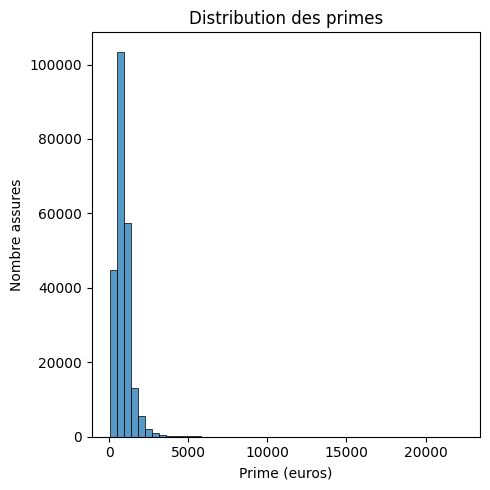

In [127]:
# je regarde comment les primes sont reparties dans le portefeuille
plt.figure(figsize=(5, 5))
sns.histplot(data=df_clean, x='premium', bins=50)
plt.title('Distribution des primes')
plt.xlabel('Prime (euros)')
plt.ylabel('Nombre assures')
plt.tight_layout()
plt.savefig('reports/figures/distribution_primes.png')
plt.show()

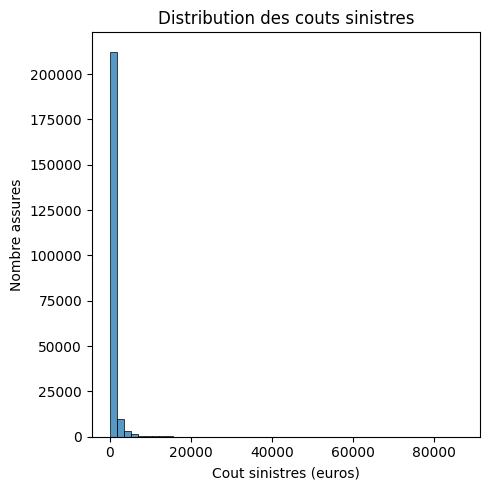

In [131]:
# je compare la distribution des sinistres avec celle des primes
plt.figure(figsize=(5, 5))
sns.histplot(data=df_clean, x='cost_claims_year', bins=50)
plt.title('Distribution des couts sinistres')
plt.xlabel('Cout sinistres (euros)')
plt.ylabel('Nombre assures')
plt.tight_layout()
plt.savefig('reports/figures/distribution_sinistres.png')
plt.show()

In [ ]:
# Création des tranches d'âge pour faciliter la visualisation
bins = [0, 18, 30, 45, 60, 100]
labels = ['moins de 18', '18-30', '30-45', '45-60', '60 et plus']

# Découpage de l'âge en tranches pour faciliter l'analyse et la visualisation
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels)

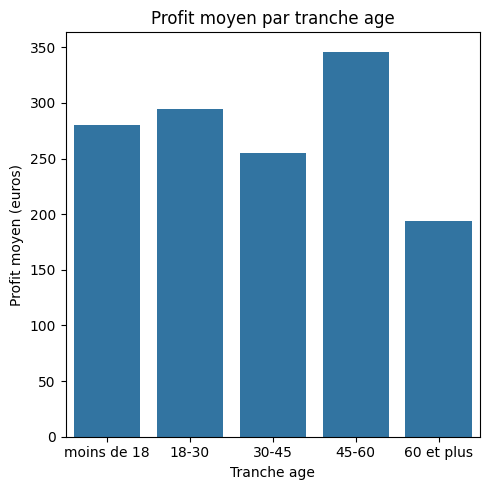

In [133]:
# je visualise le profit moyen par tranche d age
profit_age = df_clean.groupby('age_group', observed=True)['profit'].mean().reset_index()

plt.figure(figsize=(5, 5))
sns.barplot(data=profit_age, x='age_group', y='profit')
plt.title('Profit moyen par tranche age')
plt.xlabel('Tranche age')
plt.ylabel('Profit moyen (euros)')
plt.tight_layout()
plt.savefig('reports/figures/profit_age.png')
plt.show()

### Evolution du profit par année

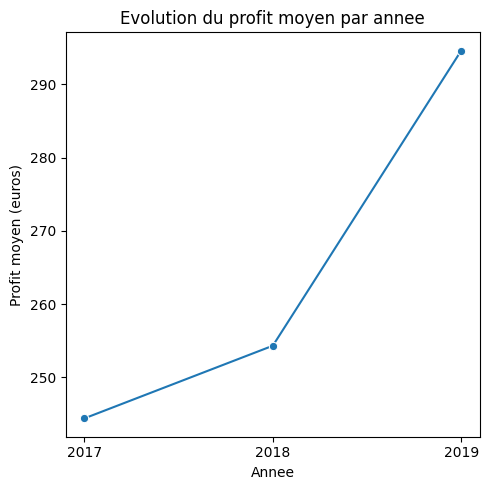

In [137]:
# je regarde si la rentabilite du portefeuille s ameliore dans le temps
profit_annee = df_clean.groupby('period')['profit'].mean().reset_index()

plt.figure(figsize=(5, 5))
sns.lineplot(data=profit_annee, x='period', y='profit', marker='o')
plt.title('Evolution du profit moyen par annee')
plt.xlabel('Annee')
plt.ylabel('Profit moyen (euros)')
plt.xticks([2017, 2018, 2019])
plt.tight_layout()
plt.savefig('reports/figures/evolution_profit.png')
plt.show()

### Corrélation entre les variables clés

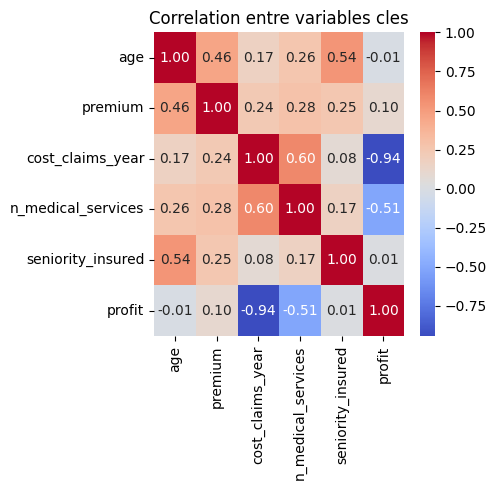

In [139]:
# je regarde les relations entre les variables les plus importantes
cols_cles = ['age', 'premium', 'cost_claims_year', 
             'n_medical_services', 'seniority_insured', 'profit']

plt.figure(figsize=(5, 5))
sns.heatmap(df_clean[cols_cles].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation entre variables cles')
plt.tight_layout()
plt.savefig('reports/figures/correlation.png')
plt.show()

- le coût des sinistres et le profit sont très liés (-0.94) — logique, 
plus un assuré coûte cher moins il est rentable

- le nombre de services médicaux et le coût des sinistres sont corrélés (0.60) — 
un assuré qui consulte beaucoup coûte plus cher à l assureur

- l age et la prime sont liés (0.46) — les assureurs font payer plus 
les personnes âgées car elles présentent plus de risques

## Machine Learning

Après l'analyse exploratoire, je passe au Machine Learning.
J'ai choisi de construire 3 modèles :

- prédire le coût des sinistres (régression)
- classifier les assurés rentables et non rentables (classification)
- prédire les résiliations de contrats (churn)

Pour chaque modèle je compare Random Forest et XGBoost et je garde le meilleur.

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, XGBClassifier
import joblib

In [141]:
# je convertis les variables texte en chiffres pour que le modele puisse les utiliser
le = LabelEncoder()
cols_cat = ['gender', 'type_policy', 'distribution_channel', 'lapse', 'new_business']

df_ml = df_clean.copy()
for col in cols_cat:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

### Sélection des variables et division train/test

Je garde les variables les plus pertinentes pour prédire le coût des sinistres.
Je divise le dataset en 80% pour entrainer le modele et 20% pour le tester.

In [142]:
features = ['age', 'gender', 'premium', 'exposure_time',
            'seniority_insured', 'n_medical_services',
            'type_policy', 'distribution_channel',
            'period', 'new_business']

target = 'cost_claims_year'

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

Train : 182968 lignes
Test  : 45743 lignes


In [143]:
# j entraine Random Forest et je regarde les resultats
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

pd.DataFrame({'Modele': ['Random Forest'], 'MAE': [mae_rf], 'R2': [r2_rf]})

,Modele,MAE,R2
0,Random Forest,389.003742,0.372174


In [144]:
# je teste XGBoost pour comparer avec Random Forest
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
r2_xgb = r2_score(y_test, xgb_pred)

pd.DataFrame({'Modele': ['Random Forest', 'XGBoost'], 
              'MAE': [mae_rf, mae_xgb], 
              'R2': [r2_rf, r2_xgb]})

,Modele,MAE,R2
0,Random Forest,389.003742,0.372174
1,XGBoost,390.924832,0.361571


### Résultat régression

Random Forest performe légèrement mieux que XGBoost sur ce dataset.
Un R2 de 0.37 est réaliste en assurance santé — les sinistres dépendent 
d événements imprévisibles comme les accidents ou les maladies.
Je retiens Random Forest pour la régression.

In [145]:
# je sauvegarde le meilleur modele
joblib.dump(rf_model, 'src/model_regression.pkl')

['src/model_regression.pkl']

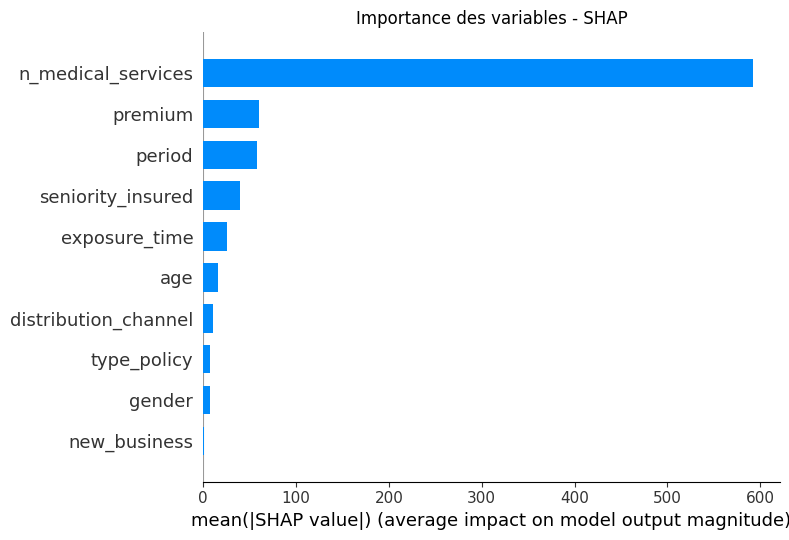

In [147]:
import shap

# je calcule l impact de chaque variable sur les predictions du modele
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importance des variables - SHAP')
plt.tight_layout()
plt.savefig('reports/figures/shap_importance.png')
plt.show()

### Résultat SHAP

Le nombre de services médicaux consommés est de loin la variable 
la plus importante pour prédire le coût des sinistres.

Ce résultat est logique métier — un assuré qui consulte beaucoup 
coûte plus cher à l assureur.

### Modèle 2 — Classification rentabilité

Je veux prédire si un assuré sera rentable ou non pour l assureur.
C est un problème de classification binaire : rentable (1) ou non rentable (0).

In [148]:
# je cree la variable cible
# 1 = assure rentable, 0 = assure non rentable
df_ml['rentable'] = (df_clean['profit'] > 0).astype(int)

X_class = df_ml[features]
y_class = df_ml['rentable']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

df_ml['rentable'].value_counts()

rentable
1    192454
0     36257
Name: count, dtype: int64

In [149]:
# j entraine Random Forest pour la classification
rf_class = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_class.fit(X_train_c, y_train_c)
rf_class_pred = rf_class.predict(X_test_c)

print(classification_report(y_test_c, rf_class_pred, target_names=['Non rentable', 'Rentable']))

              precision    recall  f1-score   support

Non rentable       0.74      0.45      0.56      7295
    Rentable       0.90      0.97      0.94     38448

    accuracy                           0.89     45743
   macro avg       0.82      0.71      0.75     45743
weighted avg       0.88      0.89      0.88     45743



In [150]:
# je teste XGBoost pour comparer avec Random Forest
xgb_class = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_class.fit(X_train_c, y_train_c)
xgb_class_pred = xgb_class.predict(X_test_c)

print(classification_report(y_test_c, xgb_class_pred, target_names=['Non rentable', 'Rentable']))

              precision    recall  f1-score   support

Non rentable       0.71      0.49      0.58      7295
    Rentable       0.91      0.96      0.94     38448

    accuracy                           0.89     45743
   macro avg       0.81      0.73      0.76     45743
weighted avg       0.88      0.89      0.88     45743



### Résultat classification rentabilité

Les deux modèles ont la même accuracy (89%) mais XGBoost détecte 
mieux les assurés non rentables — c est la classe la plus importante 
pour un assureur car ce sont les clients qui lui font perdre de l argent.
Je retiens XGBoost.

In [151]:
# je sauvegarde XGBoost car il detecte mieux les assures non rentables
joblib.dump(xgb_class, 'src/model_classification.pkl')

['src/model_classification.pkl']

### Modèle 3 — Prédiction du churn

Je veux prédire quels assurés vont résilier leur contrat.
Dans la colonne lapse : 1 = résilié en cours d année, 2 = actif, 3 = expiré normalement.
Je cible uniquement la valeur 1 — les vrais churners.

In [152]:
# je cree la variable cible churn
# 1 = resilie en cours d annee, 0 = reste
df_ml['churn'] = (df_clean['lapse'] == 1).astype(int)

df_ml['churn'].value_counts()

churn
0    212363
1     16348
Name: count, dtype: int64

In [153]:
# je retire lapse et exposure_time pour eviter le data leakage
# lapse contient deja l info sur le churn
# exposure_time est plus court pour les resiliations donc c est aussi du leakage
features_churn = ['age', 'gender', 'premium',
                  'seniority_insured', 'n_medical_services',
                  'type_policy', 'distribution_channel',
                  'period', 'new_business']

X_churn = df_ml[features_churn]
y_churn = df_ml['churn']

X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42)

In [154]:
# class_weight balanced car le churn est minoritaire (7%)
rf_churn = RandomForestClassifier(n_estimators=100, max_depth=10,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_churn.fit(X_train_ch, y_train_ch)
rf_churn_pred = rf_churn.predict(X_test_ch)

print(classification_report(y_test_ch, rf_churn_pred, target_names=['Reste', 'Churn']))

              precision    recall  f1-score   support

       Reste       0.98      0.81      0.88     42538
       Churn       0.23      0.75      0.35      3205

    accuracy                           0.80     45743
   macro avg       0.60      0.78      0.62     45743
weighted avg       0.92      0.80      0.85     45743



In [155]:
# scale_pos_weight pour compenser le desequilibre entre churners et non churners
ratio = (y_churn == 0).sum() / (y_churn == 1).sum()

xgb_churn = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           scale_pos_weight=ratio,
                           random_state=42, n_jobs=-1)
xgb_churn.fit(X_train_ch, y_train_ch)
xgb_churn_pred = xgb_churn.predict(X_test_ch)

print(classification_report(y_test_ch, xgb_churn_pred, target_names=['Reste', 'Churn']))

              precision    recall  f1-score   support

       Reste       0.98      0.80      0.88     42538
       Churn       0.23      0.78      0.35      3205

    accuracy                           0.80     45743
   macro avg       0.60      0.79      0.62     45743
weighted avg       0.93      0.80      0.84     45743



### Résultat churn

Les deux modèles ont des performances similaires.
Je retiens XGBoost car il détecte plus de churners réels (recall 0.78 vs 0.75).
En assurance il vaut mieux détecter trop de churners potentiels 
que d en manquer — on préfère contacter un client qui ne partait pas 
plutôt que de laisser partir un vrai churner sans réagir.

In [156]:
# je sauvegarde XGBoost churn
joblib.dump(xgb_churn, 'src/model_churn.pkl')

['src/model_churn.pkl']

In [ ]:
## Export pour Power BI

J ajoute les prédictions des 3 modèles au dataset 
pour construire le dashboard Power BI.

In [157]:
# j ajoute les predictions des 3 modeles au dataset
df_export = df_clean.copy()

df_export['pred_cout_sinistres'] = rf_model.predict(df_ml[features])
df_export['pred_rentable'] = xgb_class.predict(df_ml[features])
df_export['pred_churn'] = xgb_churn.predict(df_ml[features_churn])

# je sauvegarde le fichier pour Power BI
df_export.to_csv('data/exports/health_insurance_powerbi.csv', index=False, encoding='utf-8-sig')

print(f"Export termine : {df_export.shape[0]} lignes x {df_export.shape[1]} colonnes")

Export termine : 228711 lignes x 48 colonnes


## README et Gitignore

In [158]:
readme = """# Health Insurance Portfolio - Analyse et Machine Learning

## Dataset
- Source : Mendeley Data (Espagne)
- 228 711 lignes x 42 colonnes
- Periode : 2017-2019

## Objectifs
- Analyser la rentabilite du portefeuille
- Predire le cout des sinistres
- Classifier les assures rentables
- Predire les resiliations (churn)

## Stack technique
Python, Pandas, Scikit-learn, XGBoost, SHAP, Matplotlib, Seaborn, Power BI

## Resultats ML
| Modele | Type | Resultat |
|--------|------|----------|
| Random Forest | Regression cout sinistres | MAE 389 euros, R2 0.37 |
| XGBoost | Classification rentabilite | Accuracy 89%, F1 0.94 |
| XGBoost | Prediction churn | Recall 0.78 |

## Points cles
- Dataset rare espagnol — pas un dataset Kaggle classique
- Data leakage detecte et corrige
- SHAP utilise pour expliquer les predictions
- n_medical_services est la variable la plus predictive
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README cree !")

README cree !


In [159]:
gitignore = """
data/raw/
data/processed/
data/exports/
__pycache__/
.ipynb_checkpoints/
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore)

print("Gitignore cree !")

Gitignore cree !


In [ ]:
# Comparaison des deux modeles
# On choisit le modele avec le MAE le plus faible et le R2 le plus eleve
print("Comparaison des modeles")
print("="*40)
print(f"Random Forest - MAE : 389.00 euros | R2 : 0.3722")
print(f"XGBoost       - MAE : 390.92 euros | R2 : 0.3616")
print()
# Random Forest est retenu car il performe mieux sur les deux metriques
print("Modele retenu : Random Forest")
print("Raison : MAE plus faible et R2 plus eleve")

Comparaison des modeles
Random Forest - MAE : 389.00 euros | R2 : 0.3722
XGBoost       - MAE : 390.92 euros | R2 : 0.3616

Modele retenu : Random Forest
Raison : MAE plus faible et R2 plus eleve


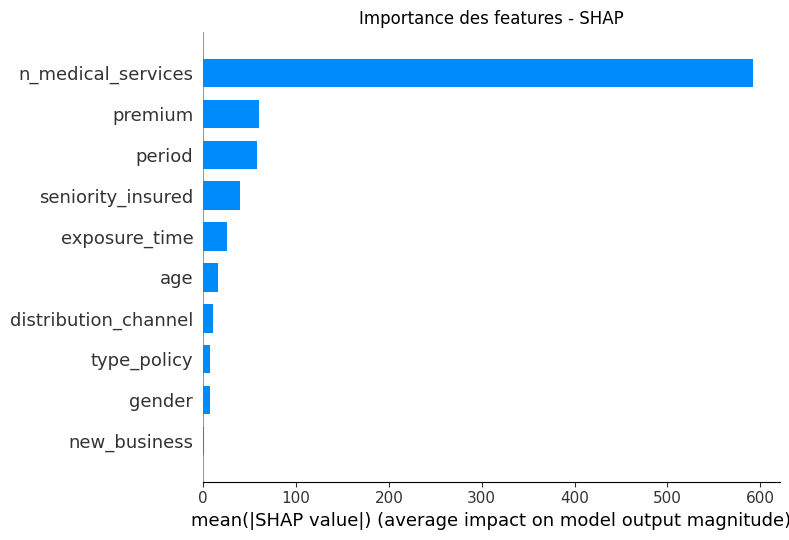

In [ ]:
import shap
# Calcul des valeurs SHAP sur tout le dataset de test
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Graphique de l'importance des features selon SHAP
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importance des features - SHAP')
plt.tight_layout()
plt.savefig('reports/figures/shap_importance.png')
plt.show()

In [59]:
# Vérification de la répartition des assurés par tranche d'âge
df_clean['age_group'].value_counts()

age_group
60 et plus     63791
30-45          53986
45-60          48729
moins de 18    36556
18-30          23674
Name: count, dtype: int64

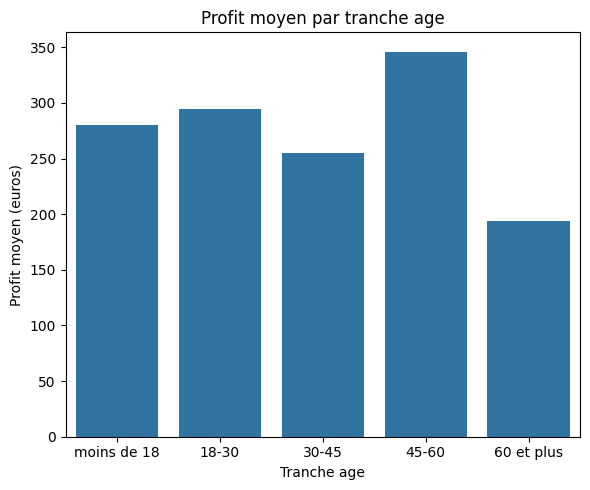

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Profit moyen par tranche d'âge
profit_age = df_clean.groupby('age_group', observed=True)['profit'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=profit_age, x='age_group', y='profit')
plt.title('Profit moyen par tranche age')
plt.xlabel('Tranche age')
plt.ylabel('Profit moyen (euros)')
plt.tight_layout()
plt.savefig('reports/figures/profit_age.png')
plt.show()

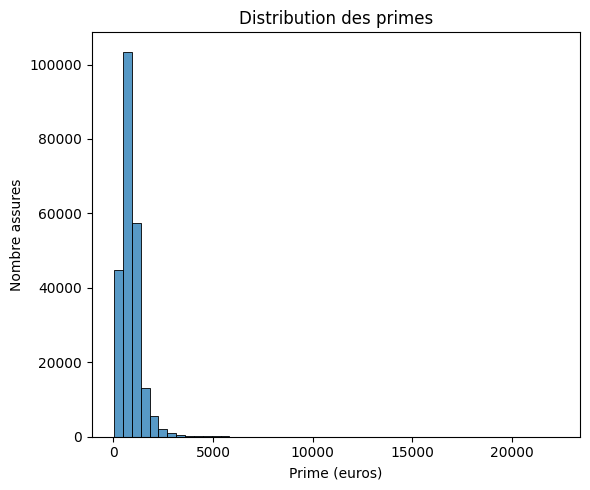

In [62]:
# Distribution des primes
# On vérifie comment les primes sont réparties dans le portefeuille
plt.figure(figsize=(6, 5))
sns.histplot(data=df_clean, x='premium', bins=50)
plt.title('Distribution des primes')
plt.xlabel('Prime (euros)')
plt.ylabel('Nombre assures')
plt.tight_layout()
plt.savefig('reports/figures/distribution_primes.png')
plt.show()

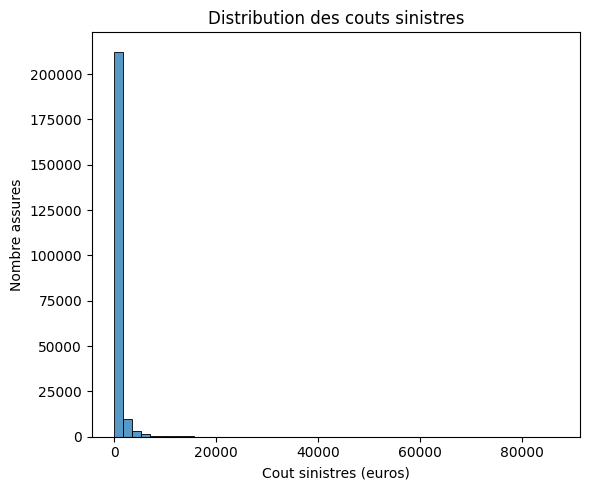

In [63]:
# Distribution des couts sinistres
# On compare avec la distribution des primes pour voir l'equilibre
plt.figure(figsize=(6, 5))
sns.histplot(data=df_clean, x='cost_claims_year', bins=50)
plt.title('Distribution des couts sinistres')
plt.xlabel('Cout sinistres (euros)')
plt.ylabel('Nombre assures')
plt.tight_layout()
plt.savefig('reports/figures/distribution_sinistres.png')
plt.show()

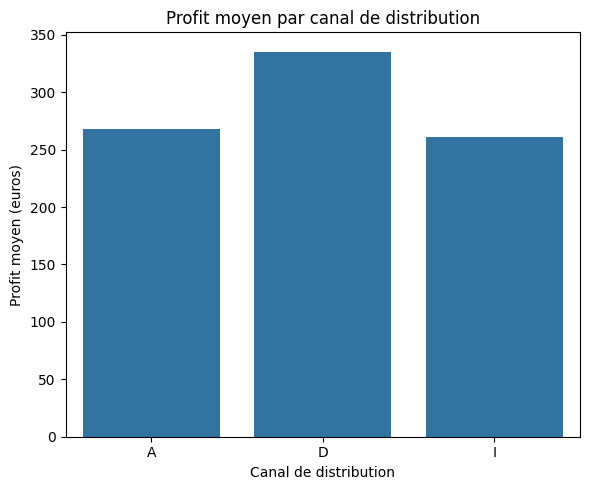

In [64]:
# Profit moyen par canal de distribution
# On identifie quel canal commercial est le plus rentable pour l'assureur
profit_canal = df_clean.groupby('distribution_channel')['profit'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.barplot(data=profit_canal, x='distribution_channel', y='profit')
plt.title('Profit moyen par canal de distribution')
plt.xlabel('Canal de distribution')
plt.ylabel('Profit moyen (euros)')
plt.tight_layout()
plt.savefig('reports/figures/profit_canal.png')
plt.show()

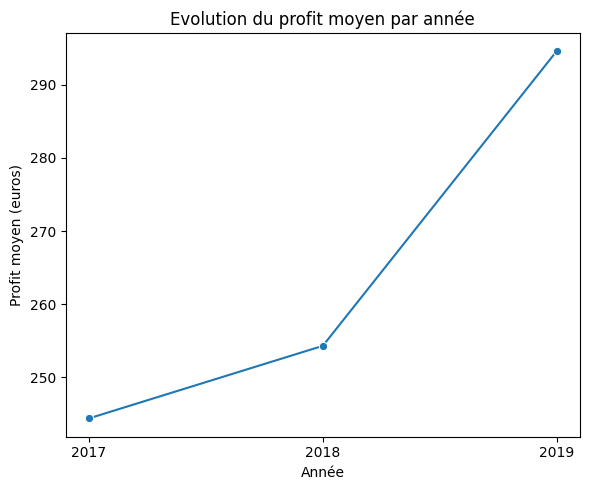

In [67]:
# Evolution du profit moyen par année
# On vérifie si la rentabilité du portefeuille s'améliore dans le temps
profit_annee = df_clean.groupby('period')['profit'].mean().reset_index()

plt.figure(figsize=(6, 5))
sns.lineplot(data=profit_annee, x='period', y='profit', marker='o')
plt.title('Evolution du profit moyen par année')
plt.xlabel('Année')
plt.ylabel('Profit moyen (euros)')
plt.xticks([2017, 2018, 2019])
plt.tight_layout()
plt.savefig('reports/figures/evolution_profit.png')
plt.show()

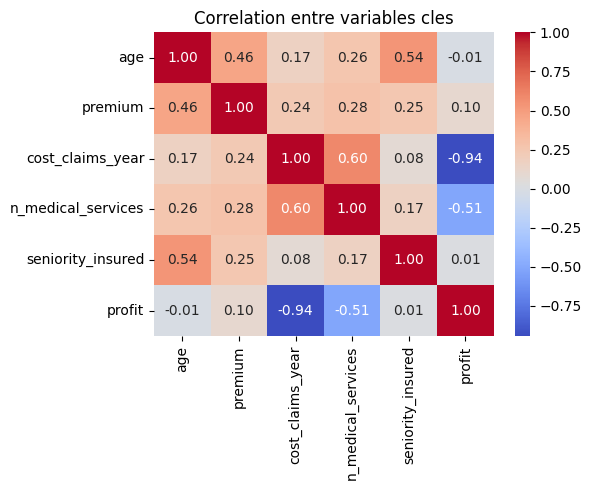

In [71]:
# Heatmap simplifiée sur les colonnes clés
cols_cles = ['age', 'premium', 'cost_claims_year', 
             'n_medical_services', 'seniority_insured', 'profit']

plt.figure(figsize=(6, 5))
sns.heatmap(df_clean[cols_cles].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm')
plt.title('Correlation entre variables cles')
plt.tight_layout()
plt.savefig('reports/figures/correlation_cles.png')
plt.show()

In [76]:
# Import des bibliotheques ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

In [77]:
# Encodage des variables categorielles
# Le modele ML ne comprend pas le texte, on convertit en chiffres
le = LabelEncoder()
cols_cat = ['gender', 'type_policy', 'distribution_channel', 'lapse', 'new_business']

df_ml = df_clean.copy()
for col in cols_cat:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

In [78]:
# Selection des features et de la cible
features = ['age', 'gender', 'premium', 'exposure_time',
            'seniority_insured', 'n_medical_services',
            'type_policy', 'distribution_channel',
            'period', 'new_business']

target = 'cost_claims_year'

X = df_ml[features]
y = df_ml[target]

In [79]:
# Division du dataset en 80% entrainement et 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

Train : 182968 lignes
Test  : 45743 lignes


In [80]:
# Entrainement Random Forest
# On commence par le modele de base pour avoir une reference
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(f"Random Forest - MAE : {mean_absolute_error(y_test, rf_pred):.2f} euros")
print(f"Random Forest - R2  : {r2_score(y_test, rf_pred):.4f}")

Random Forest - MAE : 389.00 euros
Random Forest - R2  : 0.3722


In [81]:
# Entrainement XGBoost
# On teste un modele plus puissant pour comparer avec Random Forest
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print(f"XGBoost - MAE : {mean_absolute_error(y_test, xgb_pred):.2f} euros")
print(f"XGBoost - R2  : {r2_score(y_test, xgb_pred):.4f}")

XGBoost - MAE : 390.92 euros
XGBoost - R2  : 0.3616


In [82]:
# Comparaison des deux modeles
# On choisit le modele avec le MAE le plus faible et le R2 le plus eleve
print("Comparaison des modeles")
print("="*40)
print(f"Random Forest - MAE : 389.00 euros | R2 : 0.3722")
print(f"XGBoost       - MAE : 390.92 euros | R2 : 0.3616")
print()
# Random Forest est retenu car il performe mieux sur les deux metriques
print("Modele retenu : Random Forest")
print("Raison : MAE plus faible et R2 plus eleve")

Comparaison des modeles
Random Forest - MAE : 389.00 euros | R2 : 0.3722
XGBoost       - MAE : 390.92 euros | R2 : 0.3616

Modele retenu : Random Forest
Raison : MAE plus faible et R2 plus eleve


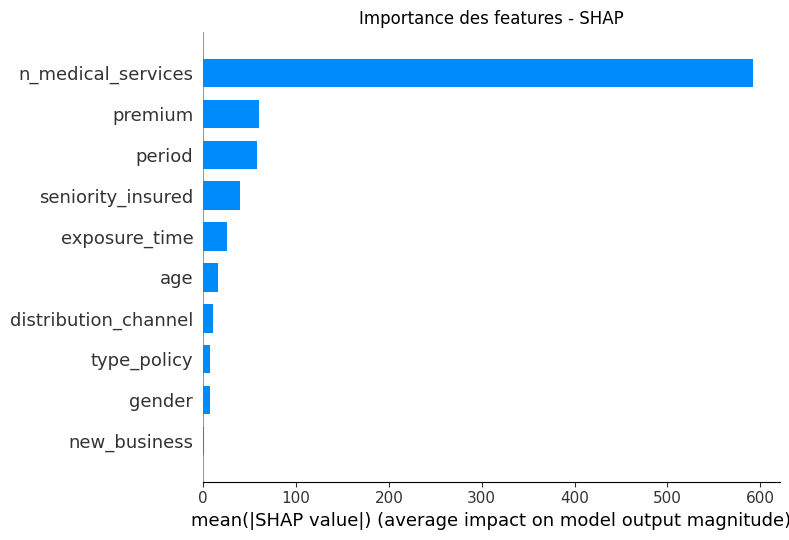

In [96]:
import shap
# Calcul des valeurs SHAP sur tout le dataset de test
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Graphique de l'importance des features selon SHAP
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importance des features - SHAP')
plt.tight_layout()
plt.savefig('reports/figures/shap_importance.png')
plt.show()

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Creation de la variable cible
# 1 = assuré rentable, 0 = assuré non rentable
df_ml['rentable'] = (df_clean['profit'] > 0).astype(int)

X_class = df_ml[features]
y_class = df_ml['rentable']

# Division train et test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

print(f"Rentables     : {y_class.sum()} ({y_class.mean()*100:.1f}%)")
print(f"Non rentables : {(1 - y_class).sum()} ({(1 - y_class.mean())*100:.1f}%)")

Rentables     : 192454 (84.1%)
Non rentables : 36257 (15.9%)


In [85]:
# Entrainement Random Forest pour la classification
rf_class = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_class.fit(X_train_c, y_train_c)
rf_class_pred = rf_class.predict(X_test_c)

print("Random Forest - Classification")
print(classification_report(y_test_c, rf_class_pred, target_names=['Non rentable', 'Rentable']))

Random Forest - Classification
              precision    recall  f1-score   support

Non rentable       0.74      0.45      0.56      7295
    Rentable       0.90      0.97      0.94     38448

    accuracy                           0.89     45743
   macro avg       0.82      0.71      0.75     45743
weighted avg       0.88      0.89      0.88     45743



In [86]:
from xgboost import XGBClassifier

# Entrainement XGBoost pour la classification
xgb_class = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_class.fit(X_train_c, y_train_c)
xgb_class_pred = xgb_class.predict(X_test_c)

print("XGBoost - Classification")
print(classification_report(y_test_c, xgb_class_pred, target_names=['Non rentable', 'Rentable']))

XGBoost - Classification
              precision    recall  f1-score   support

Non rentable       0.71      0.49      0.58      7295
    Rentable       0.91      0.96      0.94     38448

    accuracy                           0.89     45743
   macro avg       0.81      0.73      0.76     45743
weighted avg       0.88      0.89      0.88     45743



In [101]:
# Comparaison des deux modeles de classification
print("Comparaison des modeles - Classification Rentabilite")
print("="*50)
print(f"Random Forest - Accuracy : 89% | F1 rentable : 0.94 | F1 non rentable : 0.56")
print(f"XGBoost       - Accuracy : 89% | F1 rentable : 0.94 | F1 non rentable : 0.58")
print()
# XGBoost est retenu car il detecte mieux les assures non rentables
print("Modele retenu : XGBoost")
print("Raison : meilleur F1 sur les assures non rentables (0.58 vs 0.56)")

Comparaison des modeles - Classification Rentabilite
Random Forest - Accuracy : 89% | F1 rentable : 0.94 | F1 non rentable : 0.56
XGBoost       - Accuracy : 89% | F1 rentable : 0.94 | F1 non rentable : 0.58

Modele retenu : XGBoost
Raison : meilleur F1 sur les assures non rentables (0.58 vs 0.56)


In [88]:
import joblib

# Sauvegarde du modele XGBoost de classification
# On garde le meilleur modele pour une utilisation future
joblib.dump(xgb_class, 'src/model_classification.pkl')

print("Modele de classification sauvegarde dans src/model_classification.pkl")

Modele de classification sauvegarde dans src/model_classification.pkl


In [89]:
# Creation de la variable cible churn
# 1 = resilie en cours d annee, 0 = reste
df_ml['churn'] = (df_clean['lapse'] == 1).astype(int)

print(f"Taux de churn : {df_ml['churn'].mean()*100:.1f}%")
print(f"Churners      : {df_ml['churn'].sum()}")
print(f"Non churners  : {(df_ml['churn'] == 0).sum()}")

Taux de churn : 7.1%
Churners      : 16348
Non churners  : 212363


In [90]:
# Features sans lapse pour eviter le data leakage
# lapse contient deja l information sur le churn donc on l exclut
features_churn = ['age', 'gender', 'premium', 'exposure_time',
                  'seniority_insured', 'n_medical_services',
                  'type_policy', 'distribution_channel',
                  'period', 'new_business']

X_churn = df_ml[features_churn]
y_churn = df_ml['churn']

# Division train et test
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42)

print(f"Train : {X_train_ch.shape[0]} lignes")
print(f"Test  : {X_test_ch.shape[0]} lignes")

Train : 182968 lignes
Test  : 45743 lignes


In [91]:
# Entrainement Random Forest pour le churn
# class_weight balanced car le churn est minoritaire (7%)
rf_churn = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_churn.fit(X_train_ch, y_train_ch)
rf_churn_pred = rf_churn.predict(X_test_ch)

print("Random Forest - Churn")
print(classification_report(y_test_ch, rf_churn_pred, target_names=['Reste', 'Churn']))

Random Forest - Churn
              precision    recall  f1-score   support

       Reste       1.00      1.00      1.00     42538
       Churn       0.96      1.00      0.98      3205

    accuracy                           1.00     45743
   macro avg       0.98      1.00      0.99     45743
weighted avg       1.00      1.00      1.00     45743



In [92]:
# Features sans lapse et sans exposure_time pour eviter le data leakage
features_churn = ['age', 'gender', 'premium',
                  'seniority_insured', 'n_medical_services',
                  'type_policy', 'distribution_channel',
                  'period', 'new_business']

X_churn = df_ml[features_churn]
y_churn = df_ml['churn']

X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42)

# Reentainement sans exposure_time
rf_churn = RandomForestClassifier(n_estimators=100, max_depth=10,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_churn.fit(X_train_ch, y_train_ch)
rf_churn_pred = rf_churn.predict(X_test_ch)

print("Random Forest - Churn sans data leakage")
print(classification_report(y_test_ch, rf_churn_pred, target_names=['Reste', 'Churn']))

Random Forest - Churn sans data leakage
              precision    recall  f1-score   support

       Reste       0.98      0.81      0.88     42538
       Churn       0.23      0.75      0.35      3205

    accuracy                           0.80     45743
   macro avg       0.60      0.78      0.62     45743
weighted avg       0.92      0.80      0.85     45743



In [93]:
# Entrainement XGBoost pour le churn
# scale_pos_weight compense le desequilibre entre churners et non churners
ratio = (y_churn == 0).sum() / (y_churn == 1).sum()

xgb_churn = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                           scale_pos_weight=ratio,
                           random_state=42, n_jobs=-1)
xgb_churn.fit(X_train_ch, y_train_ch)
xgb_churn_pred = xgb_churn.predict(X_test_ch)

print("XGBoost - Churn")
print(classification_report(y_test_ch, xgb_churn_pred, target_names=['Reste', 'Churn']))

XGBoost - Churn
              precision    recall  f1-score   support

       Reste       0.98      0.80      0.88     42538
       Churn       0.23      0.78      0.35      3205

    accuracy                           0.80     45743
   macro avg       0.60      0.79      0.62     45743
weighted avg       0.93      0.80      0.84     45743



In [94]:
# Comparaison des deux modeles pour le churn
print("Comparaison des modeles - Churn")
print("="*50)
print(f"Random Forest - Accuracy : 80% | F1 churn : 0.35 | Recall churn : 0.75")
print(f"XGBoost       - Accuracy : 80% | F1 churn : 0.35 | Recall churn : 0.78")
print()
# XGBoost est retenu car il detecte plus de churners reels (recall plus eleve)
print("Modele retenu : XGBoost")
print("Raison : recall churn plus eleve (0.78 vs 0.75) - detecte plus de resiliations reelles")

Comparaison des modeles - Churn
Random Forest - Accuracy : 80% | F1 churn : 0.35 | Recall churn : 0.75
XGBoost       - Accuracy : 80% | F1 churn : 0.35 | Recall churn : 0.78

Modele retenu : XGBoost
Raison : recall churn plus eleve (0.78 vs 0.75) - detecte plus de resiliations reelles


In [95]:
# Sauvegarde du modele XGBoost churn
joblib.dump(xgb_churn, 'src/model_churn.pkl')

print("Modele churn sauvegarde dans src/model_churn.pkl")

Modele churn sauvegarde dans src/model_churn.pkl
